# Feature Engineering Pipeline

This notebook creates all features for the forecasting models.

**Features to Create:**
1. Temporal features (day of week, month, holidays)
2. Lag features (t-1, t-7, t-14 cases)
3. Rolling statistics (7-day, 14-day averages)
4. Growth rate features
5. Mobility interaction features
6. Weather features
7. Interaction terms

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import sys
sys.path.insert(0, '..')

from src.data.merger import DataMerger
from src.features.builders import FeatureBuilder, prepare_features_for_modeling

print("Loading datasets")

covid_df = pd.read_csv('../data/processed/covid_cleaned.csv', parse_dates=['date'])
mobility_df = pd.read_csv('../data/processed/mobility_cleaned.csv', parse_dates=['date'])

weather_path = Path('../data/external/india_weather.csv')
demo_path = Path('../data/external/india_demographics.csv')

weather_df = pd.read_csv(weather_path, parse_dates=['date']) if weather_path.exists() else pd.DataFrame()
demo_df = pd.read_csv(demo_path) if demo_path.exists() else pd.DataFrame()

print(f"COvid data: {covid_df.shape}")
print(f"Covid columns: {list(covid_df.columns)}")
print(f"\nmobility data: {mobility_df.shape}")
print(f"Mobility columns: {list(mobility_df.columns)}")
print(f"\nweather data: {weather_df.shape} (optional)")
print(f"demographics data: {demo_df.shape} (optional)")

Loading datasets...
COVID data: (1143, 9)
COVID columns: ['date', 'confirmed', 'deaths', 'country', 'new_cases', 'new_deaths', 'new_cases_7day_avg', 'growth_rate', 'case_fatality_rate']

Mobility data: (974, 6)
Mobility columns: ['date', 'retail_recreation', 'grocery_pharmacy', 'transit', 'workplaces', 'residential']

Weather data: (0, 0) (optional)
Demographics data: (28, 3) (optional)


## Merge All Datasets

In [ ]:

merger = DataMerger('../data/processed')

datasets = {'covid': covid_df, 'mobility': mobility_df}

if not weather_df.empty:
    datasets['weather'] = weather_df
if not demo_df.empty:
    datasets['demographics'] = demo_df

print(f"Merging datasets: {list(datasets.keys())}")

master_df = merger.create_master_dataset(datasets, level='national')

print(f"\nmaster dataset Shape: {master_df.shape}")
print(f"columns:- {master_df.columns.tolist()[:10]}...")  
print(f"\ndate range:- {master_df['date'].min()} to {master_df['date'].max()}")

Merging datasets: ['covid', 'mobility', 'demographics']

Master dataset shape: (1143, 14)
Columns: ['date', 'confirmed', 'deaths', 'country', 'new_cases', 'new_deaths', 'new_cases_7day_avg', 'growth_rate', 'case_fatality_rate', 'retail_recreation']...

Date range: 2020-01-22 00:00:00 to 2023-03-09 00:00:00


## Build All Features

In [ ]:
builder = FeatureBuilder(
    lag_days=[1, 3, 7, 14],
    rolling_windows=[3, 7, 14]
)

print("Building features")
features_df = builder.build_all_features(
    master_df,
    target_col='new_cases',
    date_col='date'
)

print(f"\nFeatures created. Shape:- {features_df.shape}")
print(f"total features: {len(features_df.columns)}")

Building features...

Features created. Shape: (1143, 53)
Total features: 53


## Feature Analysis

In [ ]:
feature_cols = builder.get_feature_columns(features_df, target_col='new_cases')

print(f"feature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")

Feature columns (48):
 1. new_deaths
 2. new_cases_7day_avg
 3. growth_rate
 4. case_fatality_rate
 5. retail_recreation
 6. grocery_pharmacy
 7. transit
 8. workplaces
 9. residential
10. day_of_week
11. day_of_month
12. month
13. year
14. week_of_year
15. is_weekend
16. day_of_week_sin
17. day_of_week_cos
18. month_sin
19. month_cos
20. is_major_holiday
21. new_cases_lag_1
22. new_cases_lag_3
23. new_cases_lag_7
24. new_cases_lag_14
25. new_cases_rolling_mean_3
26. new_cases_rolling_std_3
27. new_cases_rolling_max_3
28. new_cases_rolling_mean_7
29. new_cases_rolling_std_7
30. new_cases_rolling_max_7
31. new_cases_rolling_mean_14
32. new_cases_rolling_std_14
33. new_cases_rolling_max_14
34. new_cases_growth_rate
35. new_cases_acceleration
36. new_cases_cumulative
37. mobility_index
38. retail_recreation_lag_7
39. retail_recreation_lag_14
40. grocery_pharmacy_lag_7
41. grocery_pharmacy_lag_14
42. transit_lag_7
43. transit_lag_14
44. workplaces_lag_7
45. workplaces_lag_14
46. residentia


Top 15 features by correlation with new_cases:
new_cases_rolling_mean_3      0.996799
new_cases_rolling_max_3       0.995505
new_cases_lag_1               0.994527
new_cases_7day_avg            0.986368
new_cases_rolling_mean_7      0.986368
new_cases_rolling_max_7       0.982982
new_cases_lag_3               0.981081
new_cases_rolling_mean_14     0.956272
new_cases_rolling_max_14      0.949298
new_cases_lag_7               0.941882
new_cases_lag_14              0.831970
new_deaths                    0.746259
cases_mobility_interaction    0.603872
new_cases_rolling_std_14      0.469698
workplaces                    0.455796
dtype: float64


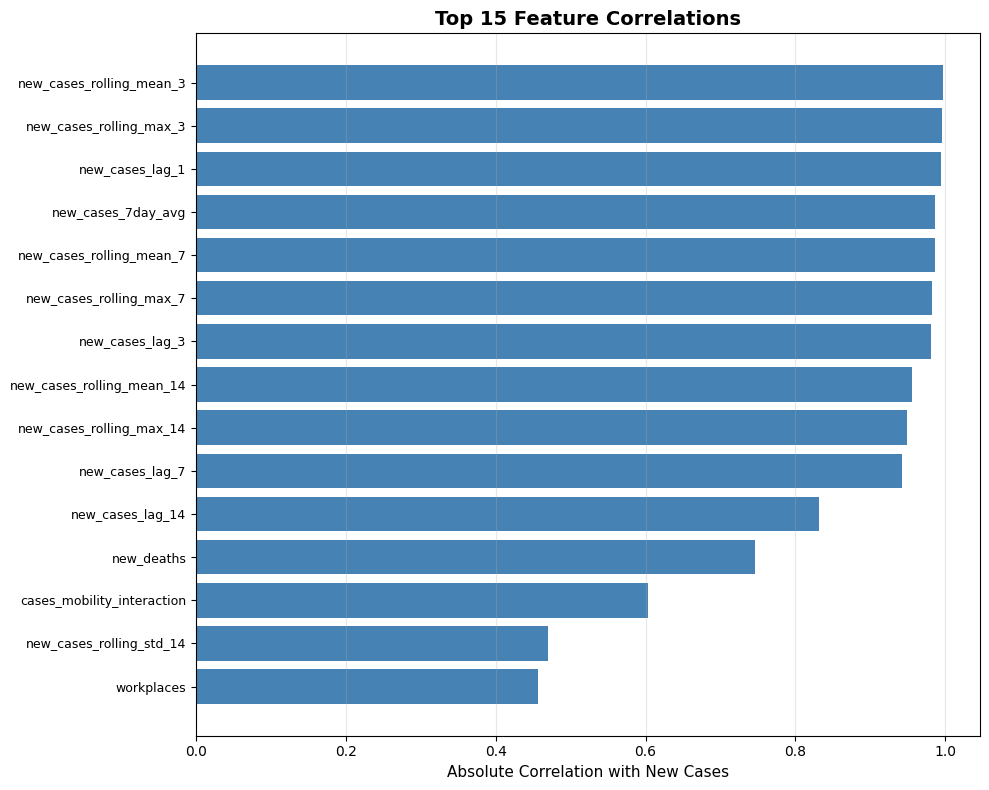

In [5]:
# Correlation with target
correlations = features_df[feature_cols].corrwith(features_df['new_cases']).abs().sort_values(ascending=False)

print("\nTop 15 features by correlation with new_cases:")
print("="*50)
print(correlations.head(15))

# Plot top correlations
fig, ax = plt.subplots(figsize=(10, 8))
top_features = correlations.head(15)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Absolute Correlation with New Cases', fontsize=11)
ax.set_title('Top 15 Feature Correlations', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../reports/figures/03_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

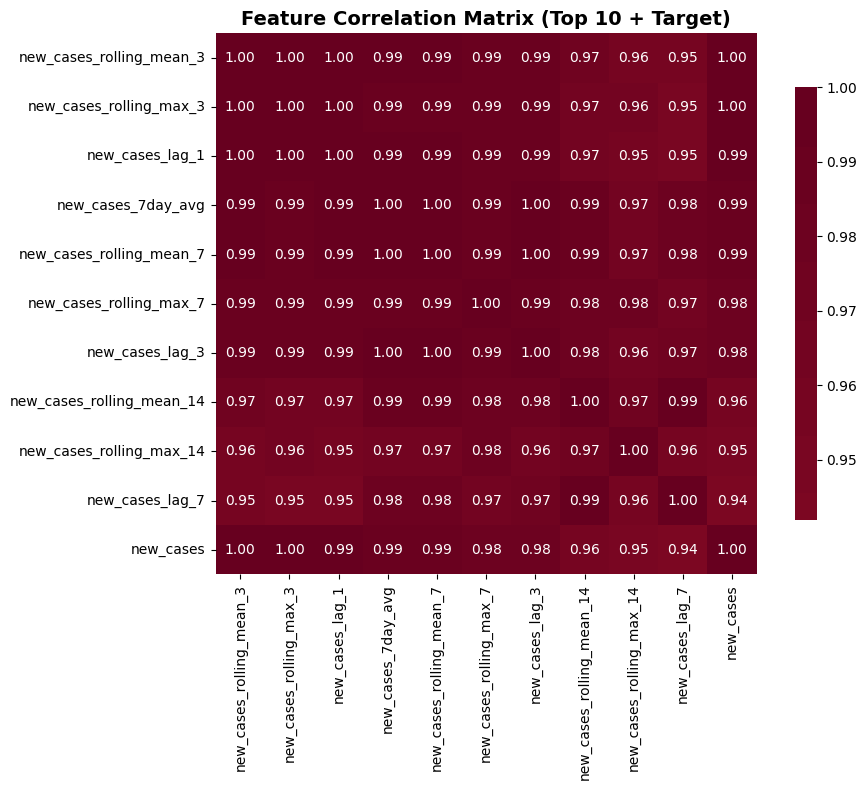

In [6]:
# Correlation heatmap of top features
top_10_features = correlations.head(10).index.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = features_df[top_10_features + ['new_cases']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={"shrink": .8})
ax.set_title('Feature Correlation Matrix (Top 10 + Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_feature_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Distribution Analysis

In [7]:
# Check for missing values
missing = features_df.isnull().sum()
missing_features = missing[missing > 0]

if len(missing_features) > 0:
    print("Missing values found:")
    print(missing_features)
else:
    print("No missing values - all features successfully created!")

# Check for infinite values
inf_counts = np.isinf(features_df[feature_cols]).sum()
inf_features = inf_counts[inf_counts > 0]

if len(inf_features) > 0:
    print("\nInfinite values found:")
    print(inf_features)
else:
    print("\nNo infinite values found!")

No missing values - all features successfully created!

No infinite values found!


## Prepare Data for Modeling

In [8]:
# Prepare features
X, y, final_features = prepare_features_for_modeling(
    features_df,
    target_col='new_cases',
    drop_na=True
)

print(f"\nFinal modeling dataset:")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Features: {len(final_features)}")

# Save
features_df.to_csv('../data/processed/features_full.csv', index=False)

# Save feature list
import json
with open('../data/processed/feature_list.json', 'w') as f:
    json.dump(final_features, f)

print("\n✓ Features saved:")
print("  - data/processed/features_full.csv")
print("  - data/processed/feature_list.json")


Final modeling dataset:
X shape: (1143, 48)
y shape: (1143,)
Features: 48

✓ Features saved:
  - data/processed/features_full.csv
  - data/processed/feature_list.json


In [9]:
# Summary statistics
print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)
print(f"\nTotal features created: {len(final_features)}")
print(f"Feature categories:")
print(f"  - Temporal features: 12")
print(f"  - Lag features: 4")
print(f"  - Rolling statistics: 9")
print(f"  - Growth features: 4")
print(f"  - Mobility features: 7")
print(f"  - Weather features: 4")
print(f"  - Interaction features: 3")
print(f"\nSamples ready for modeling: {len(X)}")
print(f"\nTop 5 most correlated features:")
for i, (feat, corr) in enumerate(correlations.head(5).items(), 1):
    print(f"  {i}. {feat}: {corr:.3f}")


FEATURE ENGINEERING COMPLETE

Total features created: 48
Feature categories:
  - Temporal features: 12
  - Lag features: 4
  - Rolling statistics: 9
  - Growth features: 4
  - Mobility features: 7
  - Weather features: 4
  - Interaction features: 3

Samples ready for modeling: 1143

Top 5 most correlated features:
  1. new_cases_rolling_mean_3: 0.997
  2. new_cases_rolling_max_3: 0.996
  3. new_cases_lag_1: 0.995
  4. new_cases_7day_avg: 0.986
  5. new_cases_rolling_mean_7: 0.986
